# Code to generate figure 3 of the paper:

In [1]:
import dill
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats

savefig=True

## Load and process results from the numerical experiment: Elliptic Ornstein Uhlenbeck CD-SSM

In [2]:
run_ids = ['5', '10', '20', '50', '100']
cdssm_str = 'mv_ou'

dfs_part_1 , dfs_part_2, dfs_part_3, metas = [], [], [], []

for run_id in run_ids:
    df_part_1 = pd.read_json(f'./results/smoothing_exp_run_{run_id}_{cdssm_str}_part_1.json')
    df_part_2 = pd.read_json(f'./results/smoothing_exp_run_{run_id}_{cdssm_str}_part_2.json')
    df_part_3 = pd.read_json(f'./results/smoothing_exp_run_{run_id}_{cdssm_str}_part_3.json')

    dfs_part_1.append(df_part_1)
    dfs_part_2.append(df_part_2)
    dfs_part_3.append(df_part_3)

    with open(f'./results/smoothing_exp_run_{run_id}_{cdssm_str}_meta.pkl', 'rb') as f:
        metadata = dill.load(f)
    metas.append(metadata)

# Concatenate the dataframes
dfs_1 = [df.copy() for df in dfs_part_1]
dfs_2 = [df.copy() for df in dfs_part_2]
dfs_3 = [df.copy() for df in dfs_part_3]

mv_ou_mae_dfs = []; mv_ou_mae_std_dfs = []; mv_ou_mae_count_dfs = []; mv_ou_mae_conf_int_dfs = []

obs_times = dfs_1[0].index.tolist()

# Selected columns of interest to plot the results:
cols = ['method', 'fk', 'cpu'] + [f'x_{i}_est_1' for i in [0] + list(range(9, 100, 10))] + [f'x_{i}_est_2' for i in [0] + list(range(9, 100, 10))]

# abs_err_df = results_df[['fk'] + [col for col in results_df.columns.tolist() if 'abs_err' in col]].copy()
# cpu_df = results_df[['fk'] + ['cpu']].copy()

for df_1, df_2, df_3 in zip(dfs_1, dfs_2, dfs_3):

    df_2 = df_2[cols]
    df_3 = df_3[cols]
    
    true_vals_df = df_1
    results_df = pd.concat([df_2, df_3], axis=0)

    for t in obs_times:
        results_df[f'x_{t}_est_1_abs_err'] = np.abs(results_df[f'x_{t}_est_1'] - true_vals_df.loc[t, f'x_t_smth_mean_1'])
        results_df[f'x_{t}_est_2_abs_err'] = np.abs(results_df[f'x_{t}_est_2'] - true_vals_df.loc[t, f'x_t_smth_mean_2'])

    abs_err_df = results_df[['fk'] + [col for col in results_df.columns.tolist() if 'abs_err' in col]].copy()
    cpu_df = results_df[['fk'] + ['cpu']].copy()

    mae_df = abs_err_df.groupby('fk').mean()
    mae_std_df = abs_err_df.groupby('fk').std()
    mae_count_df = abs_err_df.groupby('fk').count()
    mae_conf_int_df = stats.norm.ppf(0.975) * mae_std_df / np.sqrt(mae_count_df)

    mv_ou_mae_dfs.append(mae_df)
    mv_ou_mae_std_dfs.append(mae_std_df)
    mv_ou_mae_count_dfs.append(mae_count_df)
    mv_ou_mae_conf_int_dfs.append(mae_conf_int_df)

## Load and process results from the numerical experiment: Hypoelliptic Ornstein Uhlenbeck CD-SSM

In [3]:
run_ids = ['5', '10', '20', '50', '100']
cdssm_str = 'iou'

dfs_part_1 , dfs_part_2, dfs_part_3, metas = [], [], [], []

for run_id in run_ids:
    df_part_1 = pd.read_json(f'./results/smoothing_exp_run_{run_id}_{cdssm_str}_part_1.json')
    df_part_2 = pd.read_json(f'./results/smoothing_exp_run_{run_id}_{cdssm_str}_part_2.json')
    df_part_3 = pd.read_json(f'./results/smoothing_exp_run_{run_id}_{cdssm_str}_part_3.json')

    dfs_part_1.append(df_part_1)
    dfs_part_2.append(df_part_2)
    dfs_part_3.append(df_part_3)

    with open(f'./results/smoothing_exp_run_{run_id}_{cdssm_str}_meta.pkl', 'rb') as f:
        metadata = dill.load(f)
    metas.append(metadata)

# Concatenate the dataframes
dfs_1 = [df.copy() for df in dfs_part_1]
dfs_2 = [df.copy() for df in dfs_part_2]
dfs_3 = [df.copy() for df in dfs_part_3]

iou_mae_dfs = []; iou_mae_std_dfs = []; iou_mae_count_dfs = []; iou_mae_conf_int_dfs = []

obs_times = dfs_1[0].index.tolist()

# Selected columns of interest to plot the results:
cols = ['method', 'fk', 'cpu'] + [f'x_{i}_est_1' for i in [0] + list(range(9, 100, 10))] + [f'x_{i}_est_2' for i in [0] + list(range(9, 100, 10))]

abs_err_df = results_df[['fk'] + [col for col in results_df.columns.tolist() if 'abs_err' in col]].copy()
cpu_df = results_df[['fk'] + ['cpu']].copy()

for df_1, df_2, df_3 in zip(dfs_1, dfs_2, dfs_3):

    df_2 = df_2[cols]
    df_3 = df_3[cols]
    
    true_vals_df = df_1
    results_df = pd.concat([df_2, df_3], axis=0)

    for t in obs_times:
        results_df[f'x_{t}_est_1_abs_err'] = np.abs(results_df[f'x_{t}_est_1'] - true_vals_df.loc[t, f'x_t_smth_mean_1'])
        results_df[f'x_{t}_est_2_abs_err'] = np.abs(results_df[f'x_{t}_est_2'] - true_vals_df.loc[t, f'x_t_smth_mean_2'])

    abs_err_df = results_df[['fk'] + [col for col in results_df.columns.tolist() if 'abs_err' in col]].copy()
    cpu_df = results_df[['fk'] + ['cpu']].copy()

    mae_df = abs_err_df.groupby('fk').mean()
    mae_std_df = abs_err_df.groupby('fk').std()
    mae_count_df = abs_err_df.groupby('fk').count()
    mae_conf_int_df = stats.norm.ppf(0.975) * mae_std_df / np.sqrt(mae_count_df)

    iou_mae_dfs.append(mae_df)
    iou_mae_std_dfs.append(mae_std_df)
    iou_mae_count_dfs.append(mae_count_df)
    iou_mae_conf_int_dfs.append(mae_conf_int_df)

## Plot the results

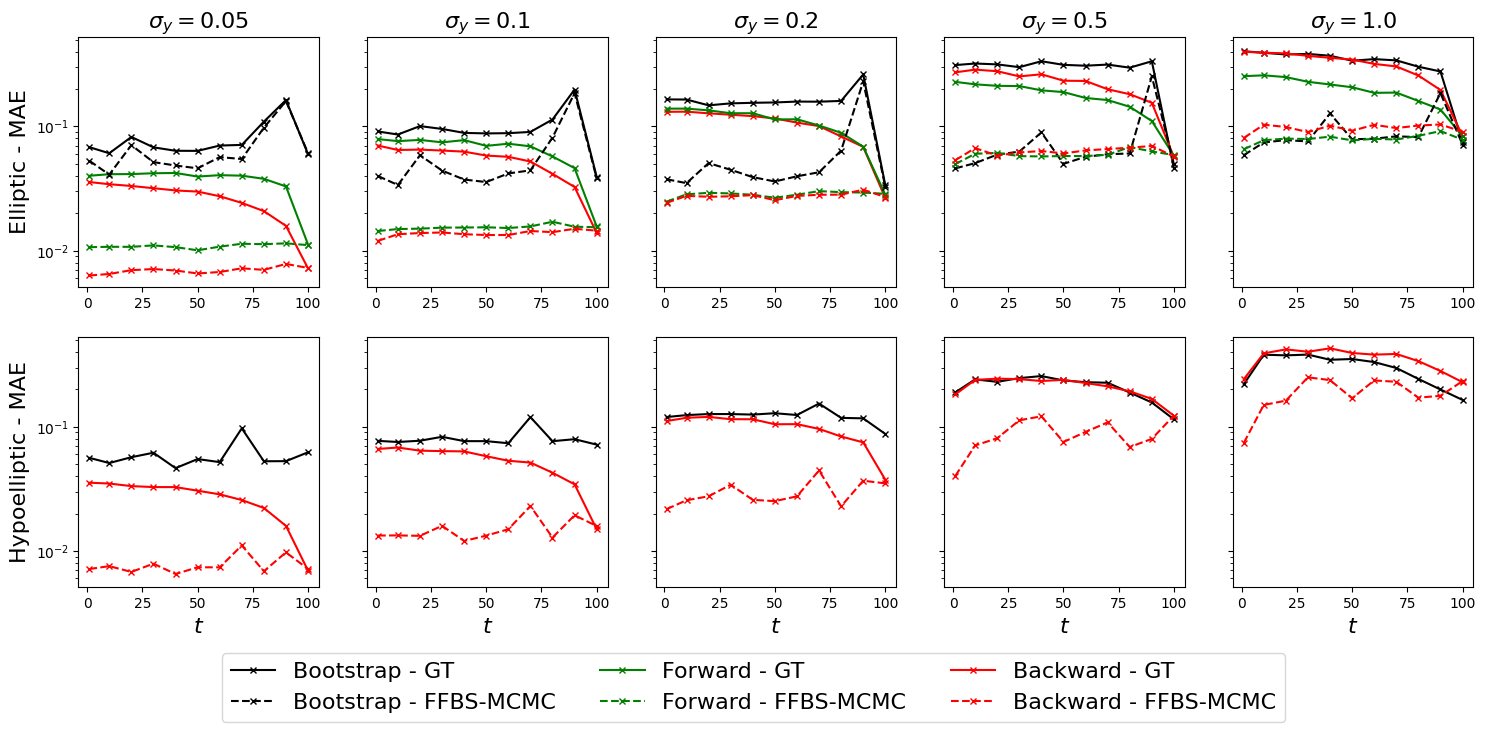

In [4]:
method_map = {'BootstrapDA': 'Bootstrap - GT', 'BwG_NDBr_OUP': 'Backward - GT', 'FwG_NDBrP': 'Forward - GT', 'BsR_DH': 'Bootstrap - FFBS-MCMC', 'FwR_DH_NDBrP': 'Forward - FFBS-MCMC', 'BwR_NDBr_OUP': 'Backward - FFBS-MCMC'} 
color_map = {'BootstrapDA': 'black', 'BwG_NDBr_OUP': 'red', 'FwG_NDBrP': 'green', 'BsR_DH': 'black', 'FwR_DH_NDBrP': 'green', 'BwR_NDBr_OUP': 'red'}
ls_map = {'BootstrapDA': '-', 'BwG_NDBr_OUP': '-', 'FwG_NDBrP': '-', 'BsR_DH': '--', 'FwR_DH_NDBrP': '--', 'BwR_NDBr_OUP': '--'}

titles = [r'$\sigma_y=0.05$', r'$\sigma_y=0.1$', r'$\sigma_y=0.2$', r'$\sigma_y=0.5$', r'$\sigma_y=1.0$']
lag=0
plot_obs_times = np.array(obs_times[lag:]) + 1
y_label = r'MAE: est of $E[X(s_t)| Y_{1:T}=y_{1:T}]$'

a = 18.; b = 9/20 * a
# plot_df_genealogy = plot_df[plot_df['method'] == 'genealogy']
# plot_§df_ffbs = plot_df[plot_df['method'] == 'FFBS_MCMC']
fig, ax = plt.subplots(2, 5, figsize=(a, b), sharey=True)
component = 1
for j, mae_df, mae_conf_int_df in zip(range(5), mv_ou_mae_dfs, mv_ou_mae_conf_int_dfs):
    plot_mae_df = mae_df[[c for c in mae_df.columns if f'_est_{component}' in c]]
    plot_mae_conf_int_df = mae_conf_int_df[[c for c in mae_df.columns if f'_est_{component}' in c]]

    for method in method_map.keys():
        mae = plot_mae_df.loc[method].to_numpy()[lag:]
        mae_err = plot_mae_conf_int_df.loc[method].to_numpy()[lag:]
        # ax[0, j].errorbar(plot_obs_times, mae, yerr=mae_err, fmt=fmt_map[method], label=method_map[method], markersize=5, capsize=4, color=color_map[method])
        ax[0, j].plot(plot_obs_times, mae, marker='x', ls=ls_map[method], label=method_map[method], markersize=5, color=color_map[method])
# ax.plot(plot_obs_times, mae_df.loc['GuidedPF'].to_numpy()[lag:], '--', label='guided', c='grey', linewidth=1.5)
        ax[0, j].set_title(titles[j], fontsize=16)

method_map = {'BootstrapDA': 'Bootstrap', 'BwG_NDBr_OUP': 'Backward', 'BwR_NDBr_OUP': None} 


i=1
for j, mae_df, mae_conf_int_df in zip(range(5), iou_mae_dfs, iou_mae_conf_int_dfs):
    plot_mae_df = mae_df[[c for c in mae_df.columns if f'_est_{component}' in c]]
    plot_mae_conf_int_df = mae_conf_int_df[[c for c in mae_df.columns if f'_est_{component}' in c]]

    for method in method_map.keys():
        mae = plot_mae_df.loc[method].to_numpy()[lag:]
        mae_err = plot_mae_conf_int_df.loc[method].to_numpy()[lag:]
        # ax[i, j].errorbar(plot_obs_times, mae, yerr=mae_err, fmt=fmt_map[method], label=method_map[method], markersize=5, capsize=4, color=color_map[method])
        ax[i, j].plot(plot_obs_times, mae, marker='x', ls=ls_map[method], label=method_map[method], markersize=5, color=color_map[method])

ax[0, 0].set_yscale('log')
ax[0, 0].set_ylabel('Elliptic - MAE', fontsize=16)
ax[1, 0].set_yscale('log')
ax[1, 0].set_ylabel('Hypoelliptic - MAE', fontsize=16)

for j in range(5):
    ax[1, j].set_xlabel(r'$t$', fontsize=16)


fig.subplots_adjust(bottom=0.2)
h, l = ax[0, 0].get_legend_handles_labels()

l_new = [l[0], l[3], l[2], l[4], l[1], l[5]]
h_new = [h[0], h[3], h[2], h[4], h[1], h[5]]

fig.legend(h_new, l_new,
           loc='lower center',
           bbox_to_anchor=(0.5, 0.02),
           ncol=len(h) // 2,
           fontsize=16)
    
if savefig:
    plt.savefig(f'./figures/fig_3_smoothing_results.pdf', bbox_inches='tight')
plt.show()